# Exam Form Recognition — OpenAI Vision API Pipeline Test

This notebook tests the recognition pipeline using the **OpenAI Vision API** (GPT-4o)
instead of the local CLIP model. The downstream grading and export pipeline is identical.

**Steps:**
1. Configure paths and API key
2. Load PDF and extract page image
3. Send image to OpenAI Vision API and inspect raw response
4. Run full pipeline via `FormRecognition` in OpenAI mode
5. Inspect recognized values
6. Grade and export to Excel
7. Multi-page test

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

%matplotlib inline
plt.rcParams["figure.figsize"] = (14, 20)
plt.rcParams["figure.dpi"] = 100

## 0. Configuration

Set your OpenAI API key below. You can also set it via the `OPENAI_API_KEY` environment variable.

In [4]:
import os

from exam_grader.config import (
    TEMPLATE_PATH, CELL_COORDS_PATH, SAVED_EXCELS_DIR,
    NUM_QUESTIONS, SCORING_WEIGHTS, ROW_NAMES,
)

# --- Set these for your test ---
PDF_PATH = "../data/valid_format/users_answears.PDF"
ANSWERS_PATH = "../data/answers.xlsx"
VERSION = 1
PAGE_INDEX = 0

# OpenAI settings
OPENAI_API_KEY = os.environ.get("OPENAI_API_KEY", "sk-...")
OPENAI_MODEL = "gpt-5.2"

print(f"Template:     {TEMPLATE_PATH}")
print(f"Cell coords:  {CELL_COORDS_PATH}")
print(f"PDF:          {PDF_PATH}")
print(f"Answers:      {ANSWERS_PATH}")
print(f"Version:      {VERSION}")
print(f"OpenAI model: {OPENAI_MODEL}")
print(f"API key set:  {OPENAI_API_KEY != 'sk-...'}")

Template:     c:\Users\zamko\Documents\vlzm\streamlit-exam-form-app\notebooks\..\data\template_raw.jpg
Cell coords:  c:\Users\zamko\Documents\vlzm\streamlit-exam-form-app\notebooks\..\data\rows_data_new_format.json
PDF:          ../data/valid_format/users_answears.PDF
Answers:      ../data/answers.xlsx
Version:      1
OpenAI model: gpt-5.2
API key set:  True


## 1. Load PDF page as image

PDF has 19 page(s)
Page image shape: (5052, 3570)


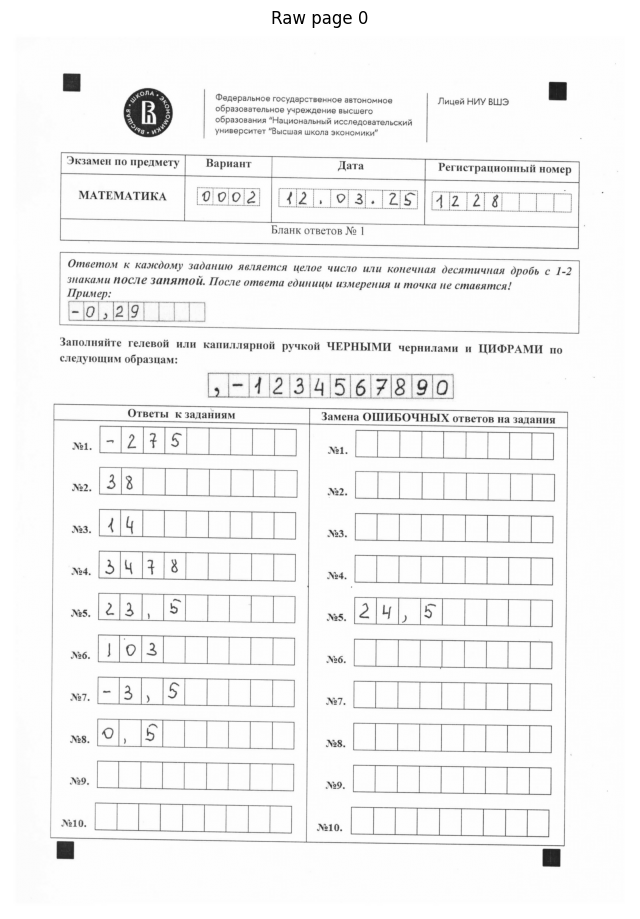

In [5]:
from exam_grader.processing.image_processing import get_page_image_from_pdf, get_pdf_page_count

with open(PDF_PATH, "rb") as f:
    pdf_bytes = f.read()

num_pages = get_pdf_page_count(pdf_bytes)
print(f"PDF has {num_pages} page(s)")

page_img = get_page_image_from_pdf(pdf_bytes, PAGE_INDEX)
print(f"Page image shape: {page_img.shape}")

plt.figure(figsize=(8, 12))
plt.imshow(page_img, cmap="gray")
plt.title(f"Raw page {PAGE_INDEX}")
plt.axis("off")
plt.show()

## 2. Test OpenAI recognizer standalone

Send the raw page image directly to the OpenAI Vision API and inspect the parsed response.

In [14]:

from exam_grader.recognition.openai_recognizer import _encode_image


b64 = _encode_image(page_img)
len(b64)

2690948

In [16]:
5052*3570

18035640

In [15]:
RECOGNITION_PROMPT = """\
Recognize this exam answer sheet image. Extract all handwritten values \
and return them as JSON with exactly the following structure:
{
  "date": "12.03.2025",
  "user_id": "1234",
  "version": "1",
  "answer_1": "275",
  "answer_2": "38",
  "answer_3": "14",
  "answer_4": "3478",
  "answer_5": "102",
  "answer_6": "3",
  "answer_7": "0,5",
  "answer_8": "18",
  "answer_9": "",
  "answer_10": "",
  "correction_1": "-275",
  "correction_2": "",
  "correction_3": "",
  "correction_4": "",
  "correction_5": "",
  "correction_6": "",
  "correction_7": "-3",
  "correction_8": "",
  "correction_9": "",
  "correction_10": ""
}

Rules:
- Pay special attention to minus signs (-) and commas (,) — don't miss them!
- Use comma as decimal separator (e.g. "0,5" not "0.5").
- Leave empty string "" for empty/unfilled fields.
- The left column contains answers ("Ответы"), the right column contains corrections ("Замена").
- Return ONLY valid JSON, nothing else.\
"""

len(RECOGNITION_PROMPT)

956

In [6]:
from exam_grader.recognition.openai_recognizer import recognize_form_with_openai

%time recognized = recognize_form_with_openai(page_img, OPENAI_API_KEY, model=OPENAI_MODEL)

print("\nRecognized values (normalized):")
for key, value in recognized.items():
    print(f"  {key:20s} = {value!r}")

CPU times: total: 1.17 s
Wall time: 7.66 s

Recognized values (normalized):
  date                 = '120325'
  user_id              = '1228'
  version              = '0002'
  answer1              = '-275'
  correction1          = ''
  answer2              = '38'
  correction2          = ''
  answer3              = '14'
  correction3          = ''
  answer4              = '3478'
  correction4          = ''
  answer5              = '23,5'
  correction5          = '24,5'
  answer6              = '103'
  correction6          = ''
  answer7              = '-3,5'
  correction7          = ''
  answer8              = '0,5'
  correction8          = ''
  answer9              = ''
  correction9          = ''
  answer10             = ''
  correction10         = ''


## 3. Full pipeline via FormRecognition (OpenAI mode)

In [7]:
from exam_grader.recognition.pipeline import FormRecognition

answers_df = pd.read_excel(ANSWERS_PATH)

recognition = FormRecognition(
    image=page_img,
    template_path=str(TEMPLATE_PATH),
    json_path=str(CELL_COORDS_PATH),
    answers=answers_df,
    version=VERSION,
)

%time result_form = recognition.run_pipeline(mode="openai", api_key=OPENAI_API_KEY, openai_model=OPENAI_MODEL)
print("Pipeline complete.")

CPU times: total: 37 s
Wall time: 11.5 s
Pipeline complete.


## 4. Inspect recognized values

In [8]:
print("Recognized answers:\n")
for name in ROW_NAMES:
    row = result_form.rows[name]
    user = row.user_answers
    correct = row.correct_answers
    joined_user = "".join(str(v) if v else "_" for v in user)
    joined_correct = "".join(str(v) if v else "_" for v in correct)
    match = "✓" if joined_user == joined_correct else "✗"
    print(f"  {name:20s}  user={joined_user:12s}  correct={joined_correct:12s}  {match}")

Recognized answers:

  date                  user=120325__      correct=              ✗
  user_id               user=1228____      correct=              ✗
  version               user=0002          correct=              ✗
  answer1               user=-275_____     correct=-98           ✗
  answer2               user=38_______     correct=240           ✗
  answer3               user=14_______     correct=0             ✗
  answer4               user=3478_____     correct=150           ✗
  answer5               user=23,5_____     correct=16,9          ✗
  answer6               user=103______     correct=280           ✗
  answer7               user=-3,5_____     correct=-8            ✗
  answer8               user=0,5______     correct=-54           ✗
  answer9               user=_________     correct=10,8          ✗
  answer10              user=_________     correct=4,5           ✗
  correction1           user=_________     correct=-98           ✗
  correction2           user=_________   

## 5. Row preview images

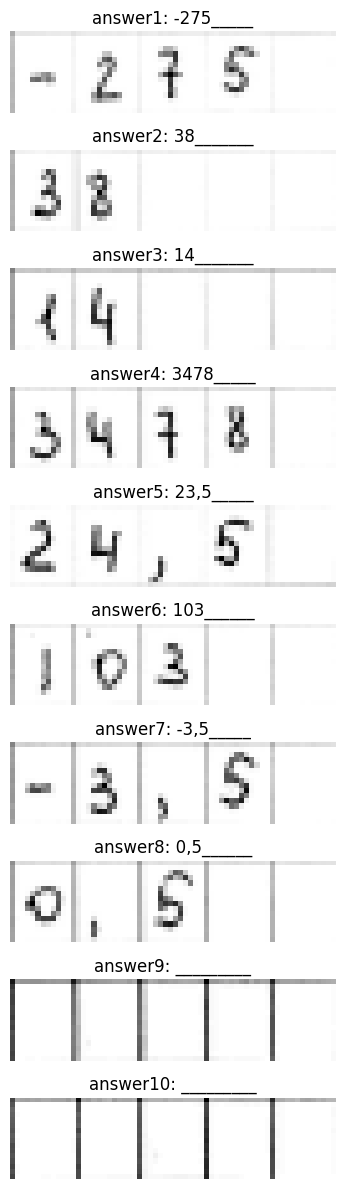

In [9]:
answer_rows = [name for name in ROW_NAMES if name.startswith("answer")]

fig, axes = plt.subplots(len(answer_rows), 1, figsize=(6, 12))
for ax, name in zip(axes, answer_rows):
    row = result_form.rows[name]
    if row.row_image is not None:
        ax.imshow(row.row_image, cmap="gray")
    ax.set_title(f"{name}: {''.join(str(v) if v else '_' for v in row.user_answers)}")
    ax.axis("off")
plt.tight_layout()
plt.show()

## 6. Grading

In [10]:
from exam_grader.export.excel import prepare_form_dict, transform_to_dataframe
from exam_grader.grading.grader import (
    get_correct_answers, postprocess_raw_output, check_answers, final_styling,
)

cur_dict = prepare_form_dict(result_form)
df = transform_to_dataframe(cur_dict)
print("Raw recognized data:")
display(df)

with open(ANSWERS_PATH, "rb") as f:
    answers_bytes = f.read()

correct = get_correct_answers(answers_bytes)
df_processed = postprocess_raw_output(df, correct, VERSION)
df_checked = check_answers(df_processed)
df_styled = final_styling(df_checked)

print("\nFinal graded results:")
display(df_styled)

Raw recognized data:


,Дата,Код участника,Вариант,Задание 1,Задание 2,Задание 3,Задание 4,Задание 5,Задание 6,Задание 7,...,Замена 1,Замена 2,Замена 3,Замена 4,Замена 5,Замена 6,Замена 7,Замена 8,Замена 9,Замена 10
0,120325,1228,0002,-275,38,14,3478,"23,5",103,"-3,5",...,,,,,"24,5",,,,,



Final graded results:


c:\Users\zamko\Documents\vlzm\streamlit-exam-form-app\notebooks\..\exam_grader\grading\grader.py:13: FutureWarning: Passing bytes to 'read_excel' is deprecated and will be removed in a future version. To read from a byte string, wrap it in a `BytesIO` object.
  df = pd.read_excel(correct_answers_path)


,Дата,Код участника,Вариант,Задание 1,Задание 2,Задание 3,Задание 4,Задание 5,Задание 6,Задание 7,...,Начисленные баллы 2,Начисленные баллы 3,Начисленные баллы 4,Начисленные баллы 5,Начисленные баллы 6,Начисленные баллы 7,Начисленные баллы 8,Начисленные баллы 9,Начисленные баллы 10,Начисленные баллы сумма
0,120325,1228,1,-275.0,38.0,14.0,3478.0,24.5,103.0,-3.5,...,0,0,0,0,0,0,0,0,0,0


## 7. Export to Excel

In [11]:
from exam_grader.export.excel import add_image_columns, save_to_excel

df_with_images = add_image_columns(df_styled)
form_dict = {0: result_form}
excel_data = save_to_excel(df_with_images, form_dict)

output_path = "../test_openai_output.xlsx"
with open(output_path, "wb") as f:
    f.write(excel_data.getvalue())

print(f"Excel saved to {output_path} ({len(excel_data.getvalue())} bytes)")

Excel saved to ../test_openai_output.xlsx (16403 bytes)


## 8. Multi-page PDF test (OpenAI mode)

Process all pages using OpenAI Vision API.

In [ ]:
df_global = pd.DataFrame()
all_forms = {}

for page_idx in range(num_pages):
    print(f"Processing page {page_idx + 1}/{num_pages}...")
    img = get_page_image_from_pdf(pdf_bytes, page_idx)
    rec = FormRecognition(
        image=img,
        template_path=str(TEMPLATE_PATH),
        json_path=str(CELL_COORDS_PATH),
        answers=answers_df,
        version=VERSION,
    )
    f = rec.run_pipeline(mode="openai", api_key=OPENAI_API_KEY, openai_model=OPENAI_MODEL)
    d = prepare_form_dict(f)
    df_cur = transform_to_dataframe(d)
    df_global = pd.concat([df_global, df_cur]).reset_index(drop=True)
    all_forms[page_idx] = f

correct = get_correct_answers(answers_bytes)
df_proc = postprocess_raw_output(df_global, correct, VERSION)
df_chk = check_answers(df_proc)
df_fin = final_styling(df_chk)
df_fin = add_image_columns(df_fin)
excel = save_to_excel(df_fin, all_forms)

with open("../test_openai_multi_page.xlsx", "wb") as f:
    f.write(excel.getvalue())
print("Multi-page export done.")

## 9. Compare CLIP vs OpenAI (optional)

Run both backends on the same page to compare recognition quality.

In [ ]:
# CLIP pipeline
rec_clip = FormRecognition(
    image=page_img,
    template_path=str(TEMPLATE_PATH),
    json_path=str(CELL_COORDS_PATH),
    answers=answers_df,
    version=VERSION,
)
%time form_clip = rec_clip.run_pipeline(mode="clip")

# OpenAI pipeline
rec_openai = FormRecognition(
    image=page_img,
    template_path=str(TEMPLATE_PATH),
    json_path=str(CELL_COORDS_PATH),
    answers=answers_df,
    version=VERSION,
)
%time form_openai = rec_openai.run_pipeline(mode="openai", api_key=OPENAI_API_KEY, openai_model=OPENAI_MODEL)

print("\n" + "-" * 70)
print(f"{'Row':<20} {'CLIP':>12} {'OpenAI':>12} {'Match':>6}")
print("-" * 70)
for name in ROW_NAMES:
    clip_val = "".join(str(v) if v else "_" for v in form_clip.rows[name].user_answers)
    oai_val = "".join(str(v) if v else "_" for v in form_openai.rows[name].user_answers)
    match = "✓" if clip_val == oai_val else "✗"
    print(f"  {name:<20} {clip_val:>12} {oai_val:>12} {match:>6}")